In [1]:
import pandas as pd
import numpy as np
from geopy import distance
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from scipy.stats import randint

In [2]:
data = pd.read_csv("cleaned_data.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109619 entries, 0 to 109618
Data columns (total 29 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   order_id                              109619 non-null  object 
 1   customer_id                           109619 non-null  object 
 2   order_status                          109619 non-null  object 
 3   order_purchase_timestamp              109619 non-null  object 
 4   order_approved_at                     109619 non-null  object 
 5   order_delivered_carrier_date          109619 non-null  object 
 6   order_delivered_customer_date         109619 non-null  object 
 7   order_estimated_delivery_date         109619 non-null  object 
 8   delay                                 109619 non-null  int64  
 9   order_item_id                         109619 non-null  int64  
 10  product_id                            109619 non-null  object 
 11  

In [4]:
# Convert date columns to datetime
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])
data['order_approved_at'] = pd.to_datetime(data['order_approved_at'])
data['order_delivered_carrier_date'] = pd.to_datetime(data['order_delivered_carrier_date'])
data['order_delivered_customer_date'] = pd.to_datetime(data['order_delivered_customer_date'])
data['order_estimated_delivery_date'] = pd.to_datetime(data['order_estimated_delivery_date'])

## Feature Selection

In [5]:
# Calculate product volume in cubic centimeters
data['product_volume_cm3'] = (
    data['product_length_cm'] * data['product_width_cm'] * data['product_height_cm']
)

# Extract day of the week and month
data['order_day_of_week'] = data['order_purchase_timestamp'].dt.dayofweek
data['order_month'] = data['order_purchase_timestamp'].dt.month

# Same state indicator
data['same_state'] = (data['geolocation_state_customer'] == data['geolocation_state_seller']).astype(int)

# Calculate the distance between sellers and customers
data['distance'] = data.apply(lambda x: distance.distance((x['geolocation_lat_seller'], x['geolocation_lng_seller']),
                                                          (x['geolocation_lat_customer'], x['geolocation_lng_customer'])).km, axis=1)

In [6]:
# Select the features that will be used in training models
data = data[['distance', 'order_day_of_week', 'order_month', 'same_state', 'delay']].copy().reset_index(drop=True)

data.head()

,distance,order_day_of_week,order_month,same_state,delay
0,18.051106,0,10,1,0
1,852.256379,1,7,0,0
2,511.820721,2,8,0,0
3,1816.652139,5,11,0,0
4,30.189028,1,2,1,0


In [7]:
data.describe()

,distance,order_day_of_week,order_month,same_state,delay
count,109619.000000,109619.000000,109619.000000,109619.000000,109619.000000
mean,595.355523,2.745090,6.031290,0.361771,0.079010
std,588.417529,1.963087,3.230674,0.480515,0.269756
min,0.000000,0.000000,1.000000,0.000000,0.000000
25%,184.019916,1.000000,3.000000,0.000000,0.000000
50%,431.637580,3.000000,6.000000,0.000000,0.000000
75%,790.242464,4.000000,8.000000,1.000000,0.000000
max,8711.002674,6.000000,12.000000,1.000000,1.000000


## Train-Validation-Test Split

In [8]:
# Features and target
X = data.drop('delay', axis=1)
y = data['delay'].copy()

In [9]:
# Create a train-test split with test size of 0.2
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# We will now split full training into training and val sets
# We make a 60-20-20 split. We need to first round to integer
train_size = int(0.75* X_train_full.shape[0])

# Finally split
X_train, X_val, y_train, y_val = X_train_full[:train_size], X_train_full[train_size:], y_train_full[:train_size], y_train_full[train_size:]

In [10]:
print('Train: ', X_train.shape, ' ', y_train.shape)
print('Validation: ', X_val.shape, ' ', y_val.shape)
print('Test: ', X_test.shape, ' ', y_test.shape)

Train:  (65771, 4)   (65771,)
Validation:  (21924, 4)   (21924,)
Test:  (21924, 4)   (21924,)


## Pre-processing pipeline

In [12]:
# Define pipelines
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

# Assign variables
num_vars = ['distance', 'order_day_of_week', 'order_month', 'same_state']

# Full preprocessor
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_vars)
])

In [13]:
# fit and transform the train set
X_train_prepared = full_pipeline.fit_transform(X_train)

# transform the validation and test set
X_val_prepared = full_pipeline.transform(X_val)
X_test_prepared = full_pipeline.transform(X_test)

## Balancing the Training Set

In [14]:
# Sampling the Dataset using SMOTE + Under Sampliing
# Create instances
smote = SMOTE(random_state=42)
under = RandomUnderSampler(random_state=42)

# Step 1: SMOTE
X_smote, y_smote = smote.fit_resample(X_train_prepared, y_train)

# Step 2: UnderSampling
X_resampled, y_resampled = under.fit_resample(X_smote, y_smote)

print('After SMOTE + UnderSampling: ', X_resampled.shape, ' ', y_resampled.shape)
print(pd.Series(y_resampled).value_counts())

After SMOTE + UnderSampling:  (121146, 4)   (121146,)
delay
0    60573
1    60573
Name: count, dtype: int64


## Logistic Regression

In [15]:
# import linear regression
from sklearn.linear_model import LogisticRegression

# create the linear regression model object
log_reg = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

# train the model
log_reg.fit(X_resampled, y_resampled)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [16]:
# Predict on train set
y_train_pred = log_reg.predict(X_resampled)

# Predict on validation set
y_val_pred = log_reg.predict(X_val_prepared)

# Classification report
print("Logistic Regression - Training Set Performance")
print(classification_report(y_resampled, y_train_pred, digits=4))

print("\n Logistic Regression - Validation Set Performance")
print(classification_report(y_val, y_val_pred, digits=4))

Logistic Regression - Training Set Performance
              precision    recall  f1-score   support

           0     0.5552    0.5421    0.5486     60573
           1     0.5527    0.5657    0.5591     60573

    accuracy                         0.5539    121146
   macro avg     0.5539    0.5539    0.5538    121146
weighted avg     0.5539    0.5539    0.5538    121146


 Logistic Regression - Validation Set Performance
              precision    recall  f1-score   support

           0     0.9345    0.5436    0.6874     20188
           1     0.0950    0.5570    0.1623      1736

    accuracy                         0.5447     21924
   macro avg     0.5148    0.5503    0.4249     21924
weighted avg     0.8680    0.5447    0.6458     21924



## Random Forest

In [17]:
# import random forest classifier
from sklearn.ensemble import RandomForestClassifier

# create the RF model
rf = RandomForestClassifier(random_state=42)

# Fit on training data
rf.fit(X_resampled, y_resampled)

RandomForestClassifier(random_state=42)

In [18]:
# Predict on train set
y_train_pred = rf.predict(X_resampled)

# Predict on validation set
y_val_pred = rf.predict(X_val_prepared)

# Classification report
print("Random Forest - Training Set Performance")
print(classification_report(y_resampled, y_train_pred, digits=4))

print("\n Random Forest - Validation Set Performance")
print(classification_report(y_val, y_val_pred, digits=4))

Random Forest - Training Set Performance
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     60573
           1     0.9997    0.9997    0.9997     60573

    accuracy                         0.9997    121146
   macro avg     0.9997    0.9997    0.9997    121146
weighted avg     0.9997    0.9997    0.9997    121146


 Random Forest - Validation Set Performance
              precision    recall  f1-score   support

           0     0.9443    0.7445    0.8325     20188
           1     0.1413    0.4891    0.2193      1736

    accuracy                         0.7242     21924
   macro avg     0.5428    0.6168    0.5259     21924
weighted avg     0.8807    0.7242    0.7840     21924



## Gradient Boosting

In [19]:
# import gradient boosting classifier
from sklearn.ensemble import GradientBoostingClassifier

# Create GB model
gb = GradientBoostingClassifier(random_state=42)

# Fit on training data
gb.fit(X_resampled, y_resampled)

GradientBoostingClassifier(random_state=42)

In [20]:
# Predict on train set
y_train_pred = gb.predict(X_resampled)

# Predict on validation set
y_val_pred = gb.predict(X_val_prepared)

# Classification report
print("Gradient Boosting - Training Set Performance")
print(classification_report(y_resampled, y_train_pred, digits=4))

print("\n Gradient Boosting - Validation Set Performance")
print(classification_report(y_val, y_val_pred, digits=4))

Gradient Boosting - Training Set Performance
              precision    recall  f1-score   support

           0     0.6902    0.7111    0.7005     60573
           1     0.7021    0.6808    0.6913     60573

    accuracy                         0.6960    121146
   macro avg     0.6962    0.6960    0.6959    121146
weighted avg     0.6962    0.6960    0.6959    121146


 Gradient Boosting - Validation Set Performance
              precision    recall  f1-score   support

           0     0.9539    0.7120    0.8154     20188
           1     0.1519    0.5997    0.2423      1736

    accuracy                         0.7031     21924
   macro avg     0.5529    0.6558    0.5289     21924
weighted avg     0.8904    0.7031    0.7700     21924



## XGBoost

In [21]:
# import XGBoost
from xgboost import XGBClassifier

# Build XGBoost Model
xgb = XGBClassifier(random_state=42)

# Fit on training data
xgb.fit(X_resampled, y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
# Predict on train set
y_train_pred = xgb.predict(X_resampled)

# Predict on validation set
y_val_pred = xgb.predict(X_val_prepared)

# Classification report
print("XGBoost - Training Set Performance")
print(classification_report(y_resampled, y_train_pred, digits=4))

print("\n XGBoost - Validation Set Performance")
print(classification_report(y_val, y_val_pred, digits=4))

XGBoost - Training Set Performance
              precision    recall  f1-score   support

           0     0.7474    0.7369    0.7421     60573
           1     0.7405    0.7510    0.7457     60573

    accuracy                         0.7439    121146
   macro avg     0.7440    0.7439    0.7439    121146
weighted avg     0.7440    0.7439    0.7439    121146


 XGBoost - Validation Set Performance
              precision    recall  f1-score   support

           0     0.9526    0.7261    0.8240     20188
           1     0.1539    0.5795    0.2432      1736

    accuracy                         0.7145     21924
   macro avg     0.5532    0.6528    0.5336     21924
weighted avg     0.8893    0.7145    0.7780     21924



## Performance Comparison

In [23]:
models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'XGBoost': xgb
}

In [24]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_val_prepared)
    y_proba = model.predict_proba(X_val_prepared)[:, 1]

    report = classification_report(y_val, y_pred, digits=4, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)

    results[name] = {
        'report': report,
        'cm': cm,
        'fpr': fpr,
        'tpr': tpr,
        'auc': auc
    }

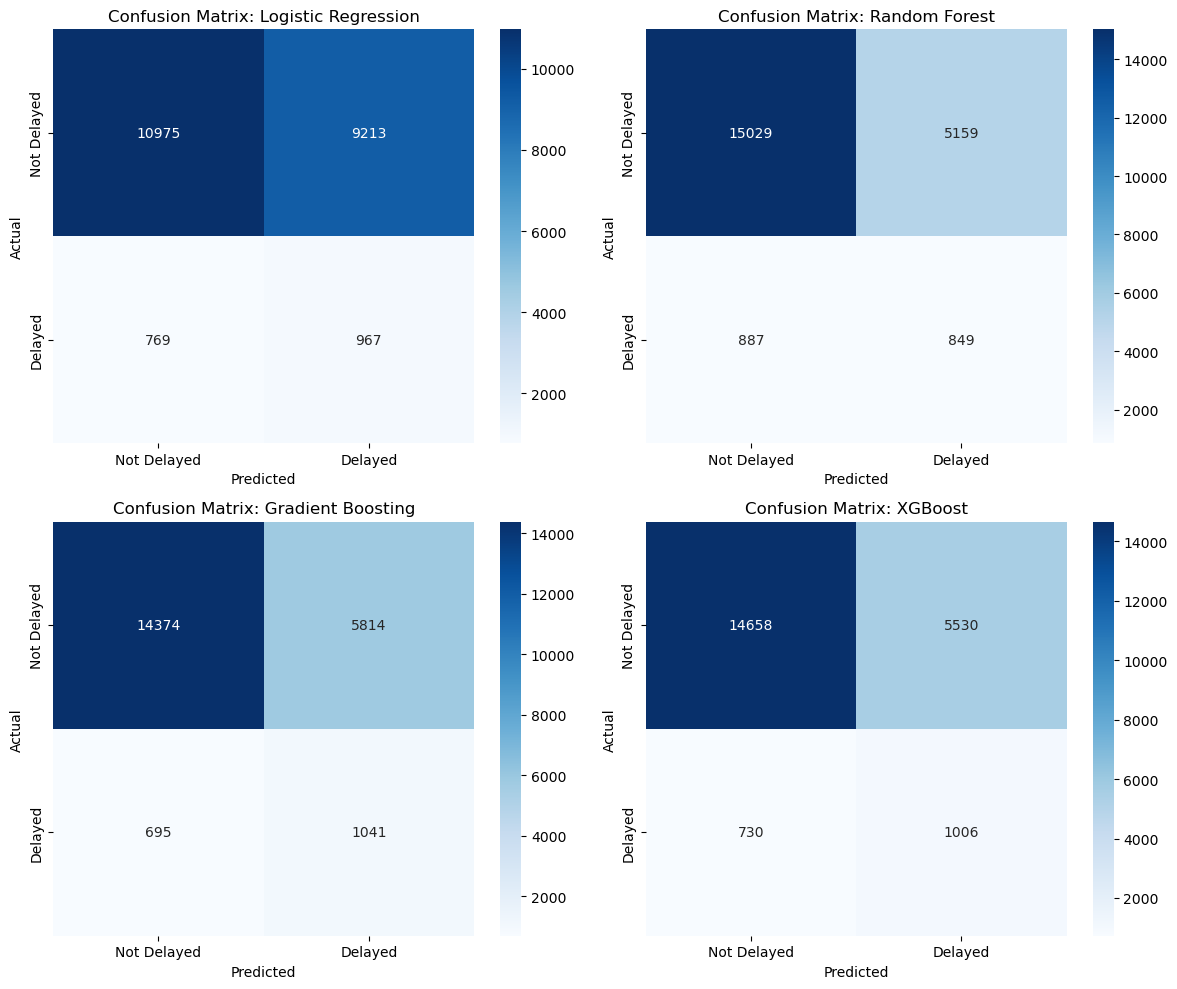

In [25]:
plt.figure(figsize=(12, 10))
for i, (name, res) in enumerate(results.items()):
    plt.subplot(2, 2, i+1)
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', xticklabels=['Not Delayed', 'Delayed'], yticklabels=['Not Delayed', 'Delayed'])
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

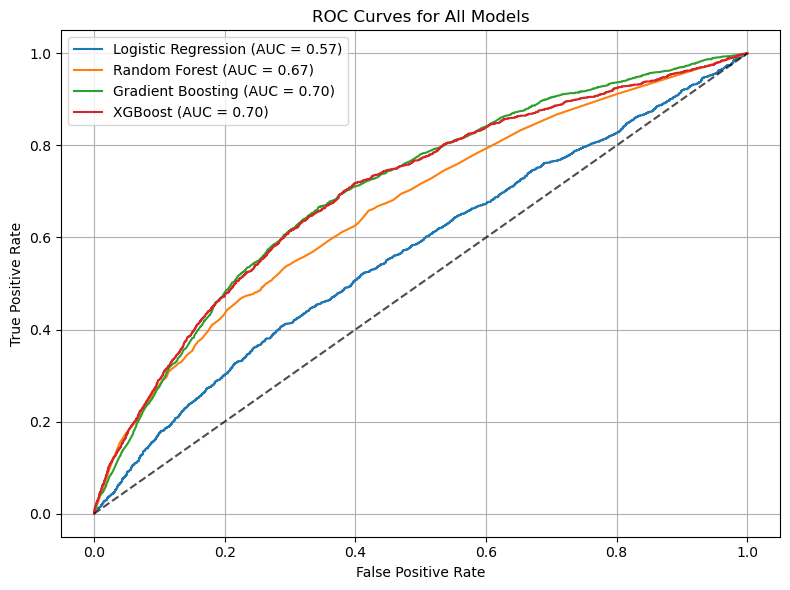

In [26]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    plt.plot(res['fpr'], res['tpr'], label=f'{name} (AUC = {res["auc"]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

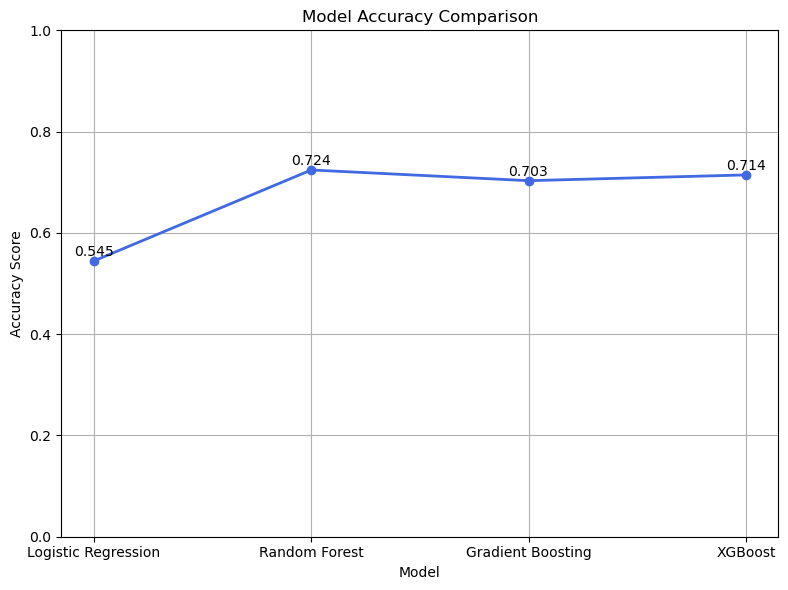

In [27]:
# Compare Accuracy scores
model_names = list(results.keys())
accuracy_scores = [res['report']['accuracy'] for res in results.values()]

plt.figure(figsize=(8, 6))

# Line plot
plt.plot(model_names, accuracy_scores, marker='o', linestyle='-', color='royalblue', linewidth=2)

# Add point labels
for i, acc in enumerate(accuracy_scores):
    plt.text(i, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=10)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
for name, res in results.items():
    print(f"\n===== {name} =====")
    print(classification_report(y_val, models[name].predict(X_val_prepared), digits=4))


===== Logistic Regression =====
              precision    recall  f1-score   support

           0     0.9345    0.5436    0.6874     20188
           1     0.0950    0.5570    0.1623      1736

    accuracy                         0.5447     21924
   macro avg     0.5148    0.5503    0.4249     21924
weighted avg     0.8680    0.5447    0.6458     21924


===== Random Forest =====
              precision    recall  f1-score   support

           0     0.9443    0.7445    0.8325     20188
           1     0.1413    0.4891    0.2193      1736

    accuracy                         0.7242     21924
   macro avg     0.5428    0.6168    0.5259     21924
weighted avg     0.8807    0.7242    0.7840     21924


===== Gradient Boosting =====
              precision    recall  f1-score   support

           0     0.9539    0.7120    0.8154     20188
           1     0.1519    0.5997    0.2423      1736

    accuracy                         0.7031     21924
   macro avg     0.5529    0.6558    

In [30]:
summary = []

for name, res in results.items():
    report = res['report']
    summary.append({
        'Model': name,
        'Precision Macro': report['macro avg']['precision'],
        'Recall Macro': report['macro avg']['recall'],
        'F1 Macro': report['macro avg']['f1-score'],
        'Accuracy': report['accuracy'],
        'ROC AUC': res['auc']
    })

summary_df = pd.DataFrame(summary)
summary_df.sort_values(by='ROC AUC', ascending=False, inplace=True)

display(summary_df)

,Model,Precision Macro,Recall Macro,F1 Macro,Accuracy,ROC AUC
2,Gradient Boosting,0.552869,0.655831,0.528865,0.703111,0.703624
3,XGBoost,0.553239,0.652784,0.533634,0.714468,0.700011
1,Random Forest,0.542791,0.616754,0.525903,0.724229,0.665331
0,Logistic Regression,0.514755,0.550334,0.424851,0.544700,0.568280


## Hyperparameter Tuning on Best Model

In [31]:
# Define parameter distributions
gb_param_dist = {
    'n_estimators': randint(1, 100),
    'learning_rate': [0.1, 0.05, 0.01],
    'max_depth': randint(3, 7)
}

# Apply Randomized Search
random_search_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_dist,
    n_iter=20,                    
    scoring='f1_macro',          
    cv=5,                       
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit to training data
random_search_gb.fit(X_resampled, y_resampled)

# Best parameters
print("Best Parameters for gb:", random_search_gb.best_params_)
print("Best CV Macro F1-score:", random_search_gb.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters for gb: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 59}
Best CV Macro F1-score: 0.7079629990346206


## Test Set Performance

In [32]:
# assign the best model to final_model object (Gradient Boosting)
final_model = random_search_gb.best_estimator_

In [33]:
y_test_pred = final_model.predict(X_test_prepared)
y_test_proba = final_model.predict_proba(X_test_prepared)[:, 1]

print(classification_report(y_test, y_test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9567    0.7151    0.8185     20197
           1     0.1573    0.6219    0.2511      1727

    accuracy                         0.7078     21924
   macro avg     0.5570    0.6685    0.5348     21924
weighted avg     0.8938    0.7078    0.7738     21924



Text(0.5, 1.0, 'Confusion Matrix (Test Set)')

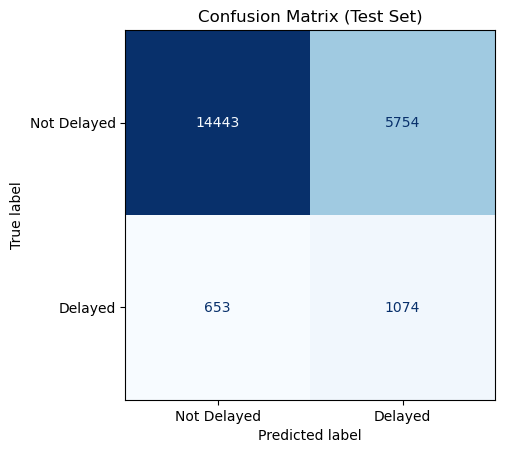

In [34]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['Not Delayed', 'Delayed'],
    cmap='Blues',
    colorbar=False
)
disp.ax_.set_title("Confusion Matrix (Test Set)")

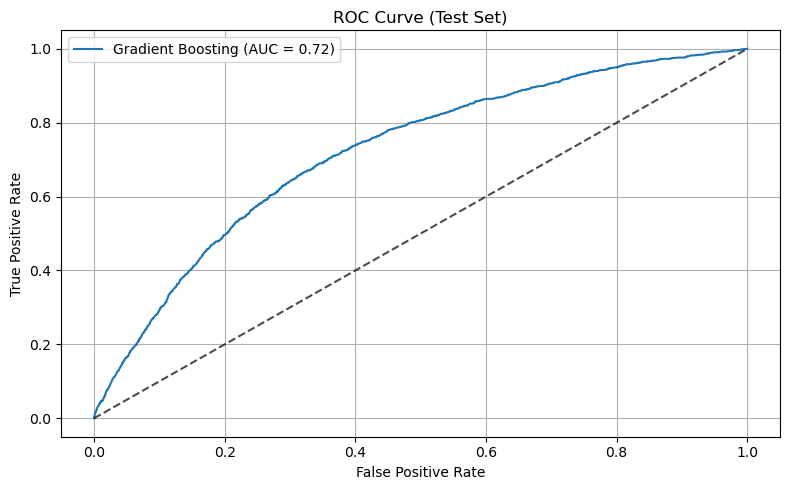

In [35]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

# Plot ROC
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()